# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Eric Ng Eng Chee



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Business Understanding



**Problem**
First time HDB buyers do not know what a fair price for HDB flats in Singapore are. This is because HDB prices can change a lot depending many factors like town, flat type, floor area, which storey it is and how much lease is left. This can cause people to overpay for their HDB by thousands of dollars.

**Target Audience**
First time HDB buyers across Singapore who have shortlisted a flat and want a quick, data based estimate before making an offer.

**Solution**
The solution is a machine learning model that predicts a fair resale price for any HDB flat in Singapore, given its details (town, flat type, floor area, storey, lease years left, etc.). The model is then implemented onto Streamlit as a web app where user picks the flat's details from dropdowns and sliders, and the app returns an estimated fair price they can compare against the seller's asking price.

**Regression**
The target "resale_price" is a continuous dollar amount, not a category, so this is a regression problem. The output has to be usable directly as a dollar value.

**Dataset**
Public HDB resale transaction data from "data.gov.sg". Covers every completed resale from January 2017 onwards (~234,000 rows) across all 26 HDB towns in Singapore. Real, non synthetic data.

**Why it matters**
Right now, most first time HDB buyers have nothing to compare an asking price against, so it is hard to tell a fair deal from an overpriced one. The solution, helps to give a quick, data based estimate to give them a benchmark. If the seller is asking far above the estimate, that is a clear signal to negotiate or walk away. Even a rough estimate is useful, because it turns a blind guess into an informed decision on a purchase worth hundreds of thousands of dollars.

# 2. Data Understanding

Before building anything, I wanted to understand what is in the data. In this section I loaded the dataset, looked at each column and its type, checked for missing values and duplicates, and visualised the data to see how prices are spread and what affects them.

Each row is one completed HDB resale transaction. There are 11 columns.

| Column | What it means |
| --- | --- |
| month | The year and month the flat was sold. |
| town | The HDB town the flat is in (e.g. TAMPINES). |
| flat_type | The type of flat (e.g. 3 ROOM, 4 ROOM). |
| block | The block number of the flat. |
| street_name | The street the flat is on. |
| storey_range | Which floors the flat sits on, given as a band (e.g. 10 TO 12). |
| floor_area_sqm | The floor area of the flat in square metres. |
| flat_model | The model of the flat (e.g. Model A, Improved). |
| lease_commence_date | The year the flat's 99 year lease started. |
| remaining_lease | How much lease is left, written as text (e.g. 61 years 04 months). |
| resale_price | The price the flat sold for, in SGD. This is the value I want to predict (the target). |

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
234667,2026-03,YISHUN,EXECUTIVE,836,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,61 years,995000.0
234668,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.0,Apartment,1987,60 years 10 months,980000.0
234669,2026-04,YISHUN,EXECUTIVE,827,YISHUN ST 81,01 TO 03,145.0,Maisonette,1987,60 years 06 months,960000.0
234670,2026-05,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,145.0,Apartment,1988,60 years 09 months,1068888.0


## 2.2 Summary Statistics

Here I checked the data types, confirmed there are no missing values, looked at the spread of each column, and counted how many unique values each column has.

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234672 entries, 0 to 234671
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                234672 non-null  object 
 1   town                 234672 non-null  object 
 2   flat_type            234672 non-null  object 
 3   block                234672 non-null  object 
 4   street_name          234672 non-null  object 
 5   storey_range         234672 non-null  object 
 6   floor_area_sqm       234672 non-null  float64
 7   flat_model           234672 non-null  object 
 8   lease_commence_date  234672 non-null  int64  
 9   remaining_lease      234672 non-null  object 
 10  resale_price         234672 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.7+ MB


In [4]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include="all")

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,234672,234672,234672,234672,234672,234672,234672.000000,234672,234672.000000,234672,2.346720e+05
unique,115,26,7,2768,578,17,NaN,21,NaN,700,NaN
top,2024-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,3036,19037,99637,707,3318,53801,NaN,84379,NaN,1924,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,96.688870,NaN,1996.559867,NaN,5.317508e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.017378,NaN,14.364676,NaN,1.906333e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,NaN,1985.000000,NaN,3.900000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1997.000000,NaN,5.000000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2012.000000,NaN,6.388880e+05


In [6]:
## Count unique values per column
df.nunique()

month                   115
town                     26
flat_type                 7
block                  2768
street_name             578
storey_range             17
floor_area_sqm          192
flat_model               21
lease_commence_date      57
remaining_lease         700
resale_price           4697
dtype: int64

## 2.3 Data Visualization

Next I plotted the data to see how the target (resale price) is spread, how each feature is distributed on its own, and how each feature relates to price.

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

count    2.346720e+05
mean     5.317508e+05
std      1.906333e+05
min      1.400000e+05
25%      3.900000e+05
50%      5.000000e+05
75%      6.388880e+05
max      1.728000e+06
Name: resale_price, dtype: float64


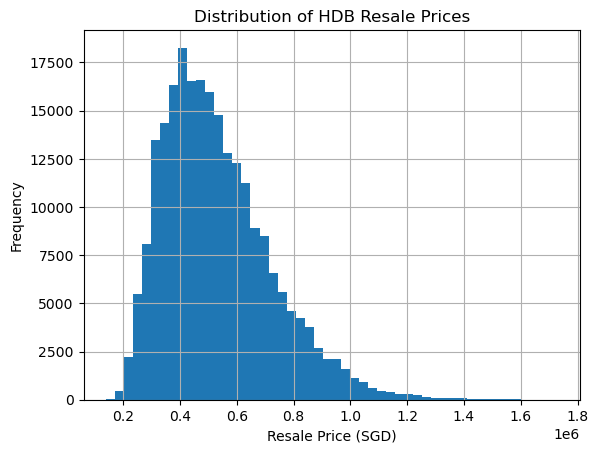

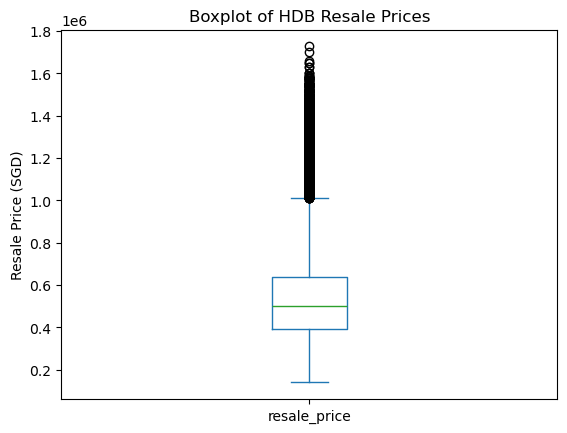

In [7]:
## Understanding distribution of target

# Target summary stats
print(df['resale_price'].describe())

# Histogram
df['resale_price'].hist(bins=50)
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Frequency')
plt.title('Distribution of HDB Resale Prices')
plt.show()
## interpretation:
# The prices are right skewed. Most flats sell between ~$390k and ~$640k, with the peak
# near ~$500k, and a long tail of premium flats stretches past $1m. Because of this skew
# the mean is pulled up by the expensive tail, so the median is a fairer summary of a
# normal flat. The skew is also why I later focus on MAE, which is not thrown off by the
# few very high prices the way RMSE is.

# Boxplot
df['resale_price'].plot(kind='box')
plt.ylabel('Resale Price (SGD)')
plt.title('Boxplot of HDB Resale Prices')
plt.show()
## interpretation:
# The median is ~$500k and the middle 50% of flats sit roughly between ~$390k and ~$640k.
# There are many outliers above the top whisker, going up to ~$1.73m. I checked these and
# they are real premium flats (large executive units in central areas), not data errors,
# so I kept them. Dropping them would make the model underprice big and high floor flats,
# which are exactly the cases a buyer might overpay on.

### 2.3.1.2 Understanding distribution of features

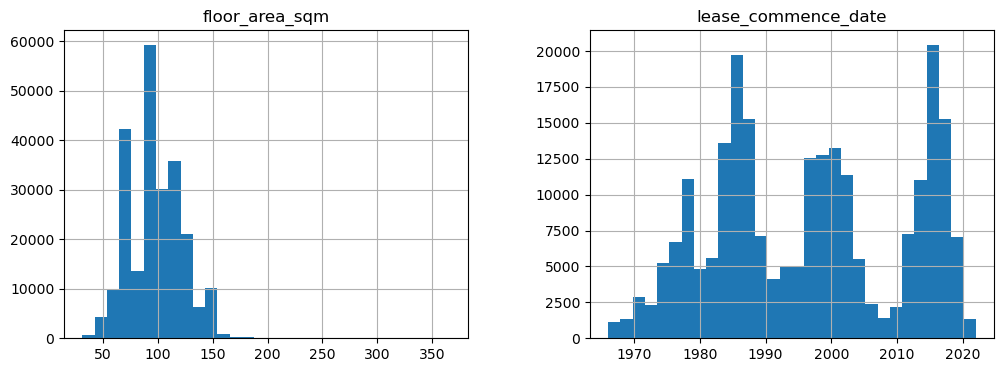

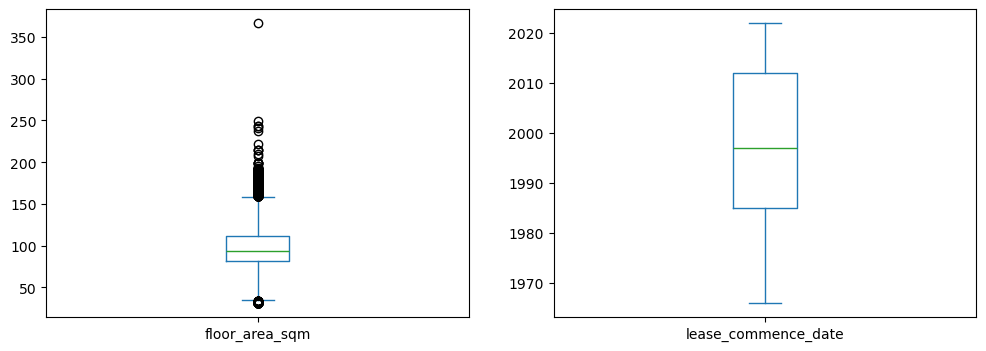

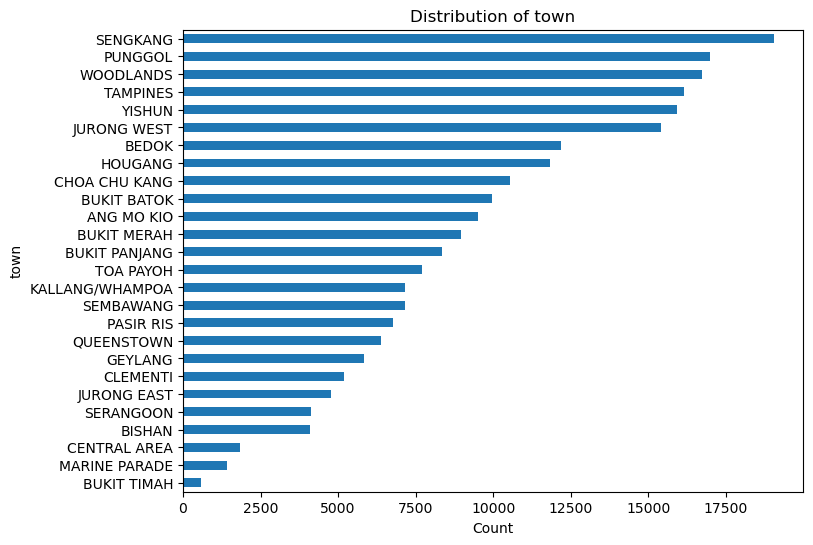

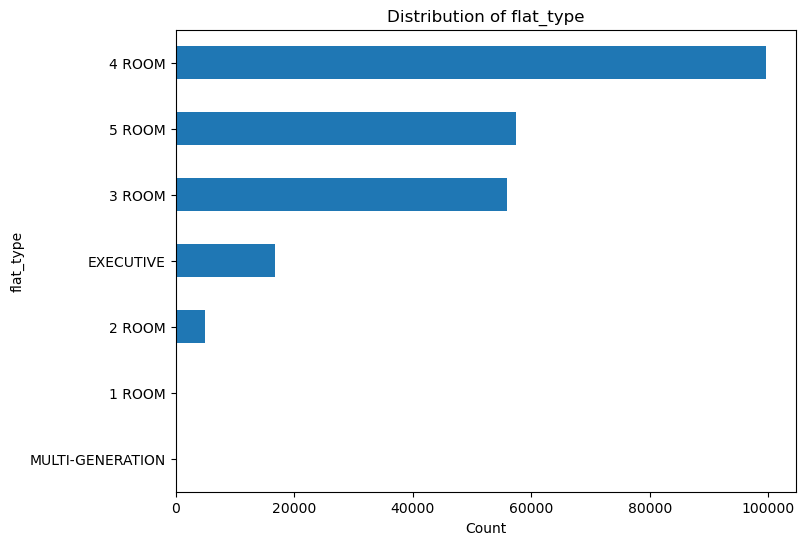

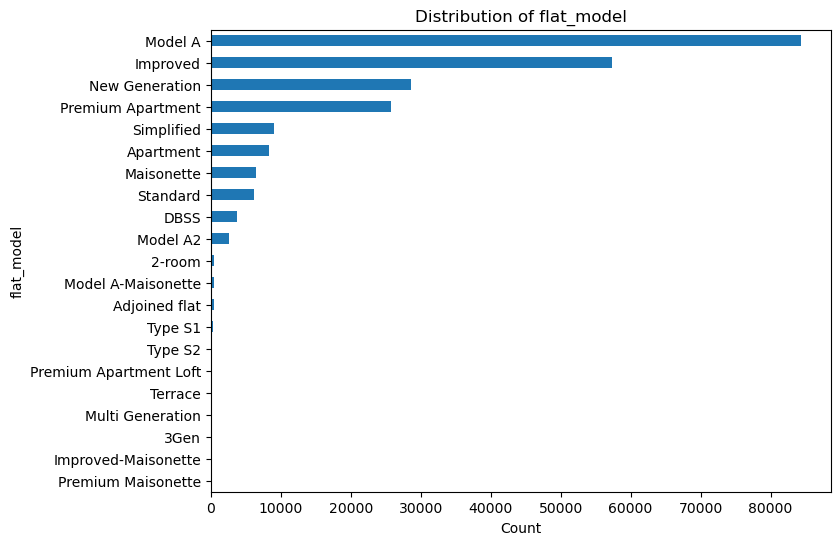

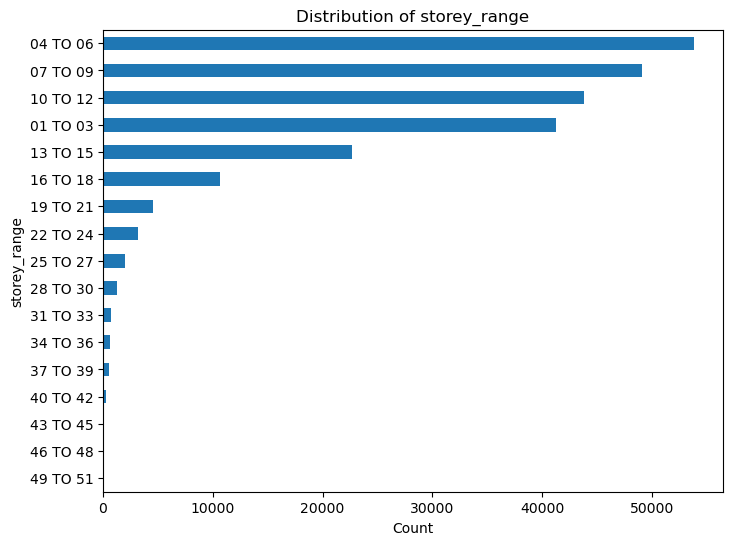

In [8]:
## Understanding distribution of features

# Numeric features (histograms)
numeric_cols = ['floor_area_sqm', 'lease_commence_date']
df[numeric_cols].hist(bins=30, figsize=(12, 4))
plt.show()
## interpretation:
# floor_area_sqm peaks around 90 to 100 sqm, which matches the common 4 ROOM flat, then
# tails off toward the larger executive units. lease_commence_date spans 1966 to 2022 and
# is spread fairly evenly, so the data covers both old and newer flats. Both are already
# numbers, so the model can use them directly.

# Numeric features (boxplots)
df[numeric_cols].plot(kind='box', subplots=True, layout=(1, 2), figsize=(12, 4))
plt.show()
## interpretation:
# floor_area_sqm has outliers on the high end (big executive flats up to ~370 sqm) and a
# few small ones (1 and 2 room flats). These are real flats, not errors, so I kept them,
# since they are part of the market the tool has to price. lease_commence_date has no
# strong outliers, so it needs no cleaning.

# Categorical features (horizontal bar charts so long labels don't overlap)
categorical_cols = ['town', 'flat_type', 'flat_model', 'storey_range']
for col in categorical_cols:
    df[col].value_counts().sort_values().plot(kind='barh', figsize=(8, 6))
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.show()
## interpretation:
# A few categories dominate the data. Most sales are 4 ROOM flats, Model A, on low floors,
# in SENGKANG and PUNGGOL. 1 ROOM and MULTI GENERATION are rare (<100 rows each). This
# imbalance means the model has plenty to learn from for common flats and predicts them
# well, but little to learn from for the rare types, so those estimates are less reliable.
# This is why I later left 1 ROOM out of the app.

### 2.3.2 Understanding relationship between variables

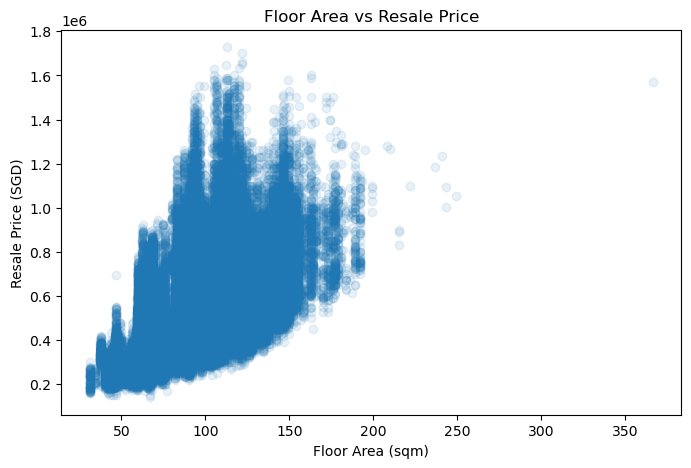

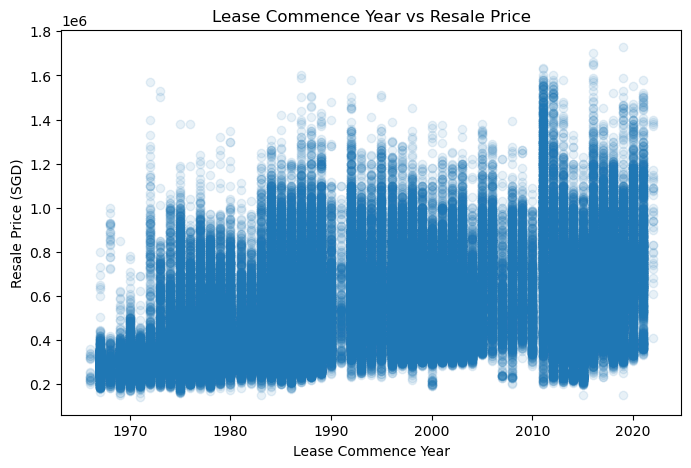

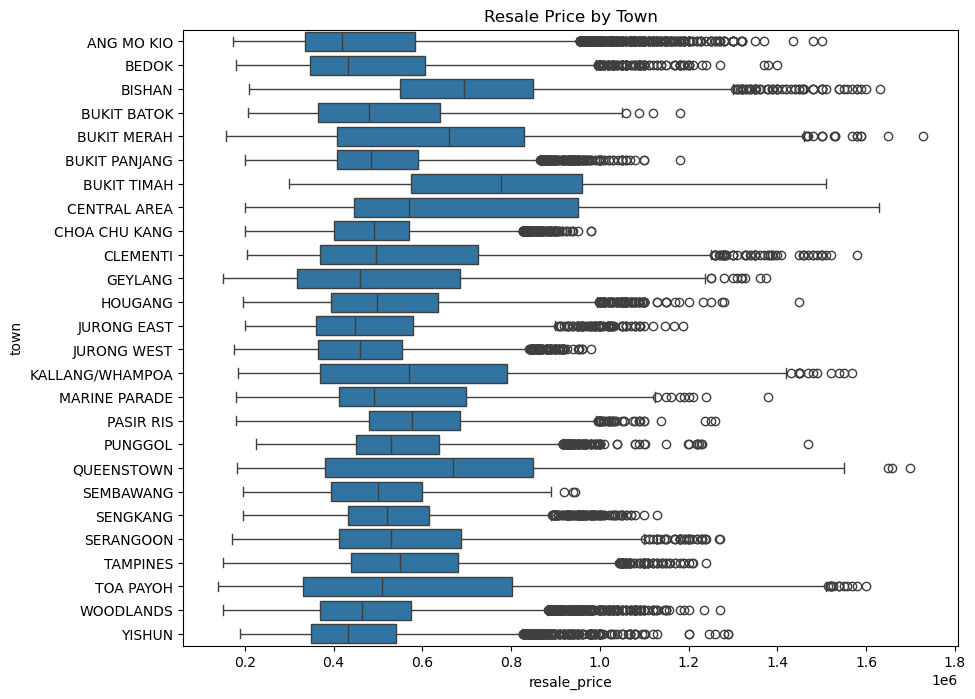

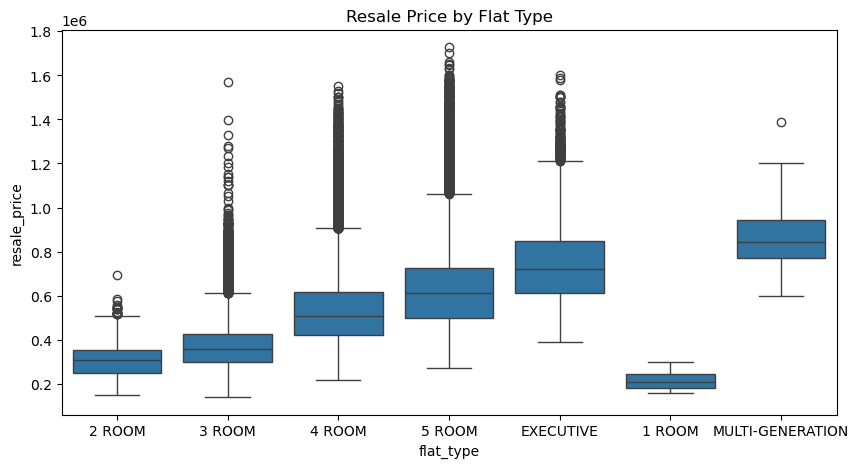

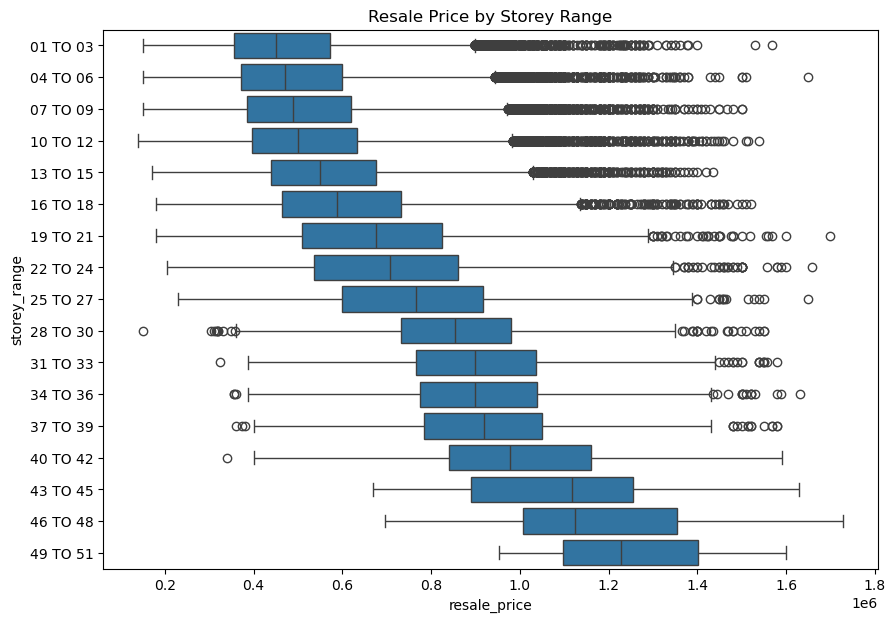

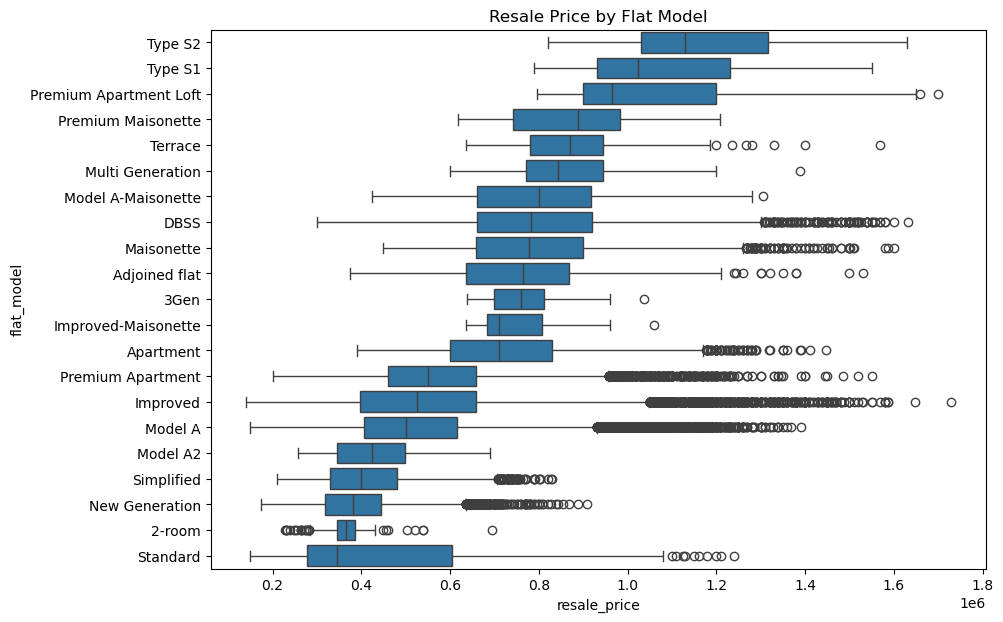

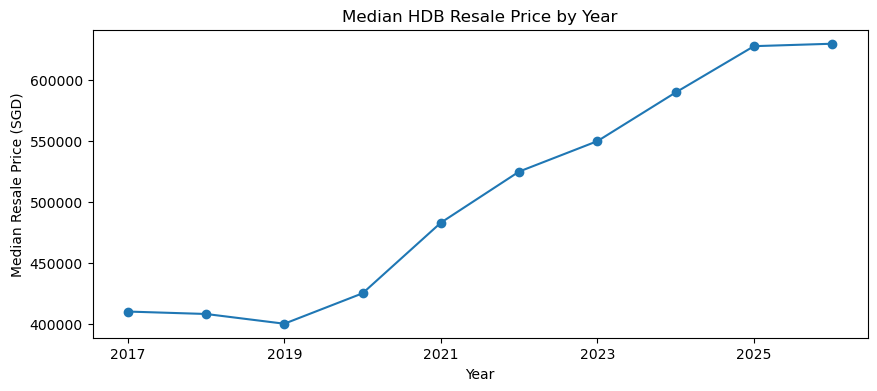

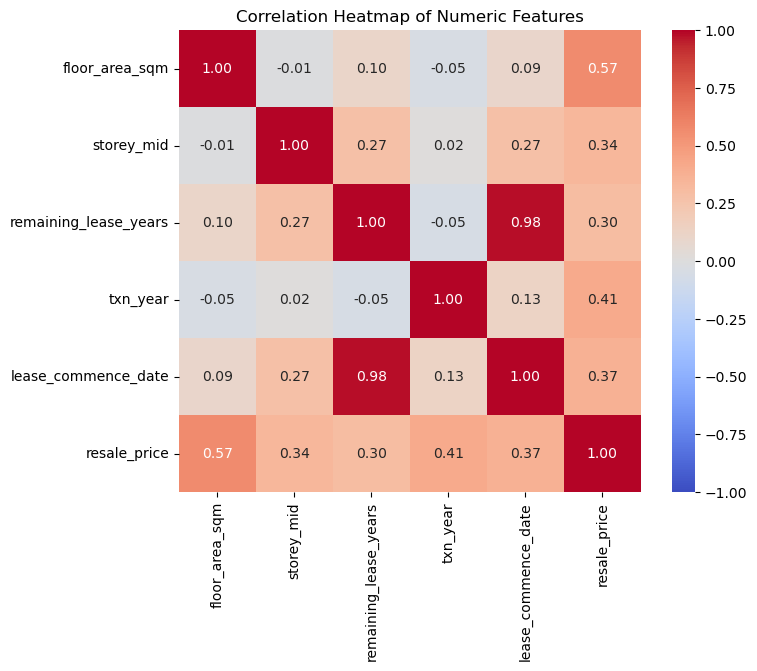

In [9]:
## Understanding relationship between variables

# Scatter: floor_area_sqm vs resale_price
plt.figure(figsize=(8, 5))
plt.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.1)
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.title('Floor Area vs Resale Price')
plt.show()
## interpretation:
# There is a strong, roughly linear positive relationship. Bigger flats cost more, and the
# points rise steadily with floor area, so floor_area_sqm is one of the most useful
# predictors (the feature importance later confirms this). The spread widens for large
# flats, which means size alone does not fully explain the price of premium units.

# Scatter: lease_commence_date vs resale_price
plt.figure(figsize=(8, 5))
plt.scatter(df['lease_commence_date'], df['resale_price'], alpha=0.1)
plt.xlabel('Lease Commence Year')
plt.ylabel('Resale Price (SGD)')
plt.title('Lease Commence Year vs Resale Price')
plt.show()
## interpretation:
# The link is positive but weaker than floor area. Newer flats tend to cost more, but there
# is a big spread of prices at each year, so lease age alone does not set the price and
# other features like town, size and storey clearly matter too. Useful, but not on its own.

# Boxplot: town vs resale_price (horizontal so all 26 town labels stay readable)
plt.figure(figsize=(10, 8))
sns.boxplot(x='resale_price', y='town', data=df)
plt.title('Resale Price by Town')
plt.show()
## interpretation:
# Town matters a lot. Central towns have the highest median (BUKIT TIMAH ~$777k) and outer
# towns the lowest (ANG MO KIO ~$418k), a gap of about $360k for otherwise similar flats.
# Location is clearly a major price driver, so I kept town as a feature and one hot encoded
# it so the model can price each town on its own.

# Boxplot: flat_type vs resale_price
plt.figure(figsize=(10, 5))
sns.boxplot(x='flat_type', y='resale_price', data=df)
plt.title('Resale Price by Flat Type')
plt.show()
## interpretation:
# Price rises clearly with flat type, from 1 ROOM at the bottom up to EXECUTIVE and MULTI
# GENERATION at the top, which matches the floor area pattern since bigger types are bigger
# flats. The ranges overlap a little (a large 4 ROOM can beat a small 5 ROOM), so flat type
# is a strong but not perfect signal, which is why the model also uses floor area.

# Boxplot: storey_range vs resale_price (horizontal, ordered from lowest floor to highest)
storey_order = sorted(df['storey_range'].unique())
plt.figure(figsize=(10, 7))
sns.boxplot(x='resale_price', y='storey_range', data=df, order=storey_order)
plt.title('Resale Price by Storey Range')
plt.show()
## interpretation:
# Price rises with storey height, from ~$450k on the lowest floors to ~$1.23m on the top
# floors, so higher units carry a clear premium. The storey_range came as text bands like
# "10 TO 12", so I turned it into a number (the midpoint) so the model can use this order
# instead of treating each band as an unrelated category.

# Boxplot: flat_model vs resale_price (horizontal, ordered by median price descending)
model_order = df.groupby('flat_model')['resale_price'].median().sort_values(ascending=False).index.tolist()
plt.figure(figsize=(10, 7))
sns.boxplot(x='resale_price', y='flat_model', data=df, order=model_order)
plt.title('Resale Price by Flat Model')
plt.show()
## interpretation:
# There is a wide range across models. Premium models sit high (Type S2 ~$1.13m) while
# common ones sit low (Standard ~$345k), so the model name carries real price information
# beyond size and location. That is why flat_model is worth keeping and one hot encoding,
# even though most individual models are not common.

# Line: median resale price by year (first 4 characters of month = YYYY)
df.groupby(df['month'].str[:4])['resale_price'].median().plot(figsize=(10, 4), marker='o')
plt.title('Median HDB Resale Price by Year')
plt.ylabel('Median Resale Price (SGD)')
plt.xlabel('Year')
plt.show()
## interpretation:
# The median price rose steadily from ~$410k in 2017 to ~$630k in 2026, about a 54% rise,
# and the climb got steeper after 2020. The year of sale clearly affects price, so I added
# a transaction year feature so the model can tell an old sale from a recent one instead of
# blending them and pricing today's flats too low.

# Correlation heatmap. I turned the text columns into numbers here just to compare all the
# numeric features with price in one view.
corr_df = pd.DataFrame({
    'floor_area_sqm': df['floor_area_sqm'],
    'storey_mid': df['storey_range'].apply(lambda t: (int(t.split(' TO ')[0]) + int(t.split(' TO ')[1])) // 2),
    'remaining_lease_years': df['remaining_lease'].str.split().str[0].astype(int),
    'txn_year': df['month'].str[:4].astype(int),
    'lease_commence_date': df['lease_commence_date'],
    'resale_price': df['resale_price'],
})
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()
## interpretation:
# floor_area_sqm has the strongest link to price (0.57), followed by txn_year (0.41),
# lease_commence_date (0.37), storey (0.34) and remaining lease (0.30), so every numeric
# feature is at least mildly useful. The key warning is that lease_commence_date and
# remaining_lease_years are almost the same thing (0.98 correlation), which is repeated
# information, so I later kept only remaining_lease_years and txn_year to avoid giving the
# linear model two near identical columns.

# 3. Data Preparation

I prepared the data in four steps.

1. **Data cleaning.** Remove duplicate rows and drop the ID columns (block, street name).
2. **Feature engineering.** Turn the text columns that hold numbers (remaining lease, storey range, month) into number columns.
3. **One hot encoding.** Turn the remaining word columns (town, flat type, flat model) into 0/1 columns.
4. **Train test split.** Split the data into a training set and a test set.

## 3.1 Data Cleaning

Before modelling, I made sure every row was clean and useful.

1. **Missing values.** Section 2.2 already showed there are none, so no imputation or row removal was needed.
2. **Duplicate rows.** Any rows that were identical across every column were dropped, so each row counts as one unique transaction.
3. **ID like columns.** I dropped `block` and `street_name`. They had too many different values (2,768 blocks, 578 streets) to be useful, and acted mainly as ID labels. `town` (only 26 values) already covers the location well enough.

I also deliberately kept the high price outliers seen during EDA, since those are real premium transactions. Removing them would make the model underprice large or high floor flats.

In [10]:
## Clean data

# Check for missing values (I saw 0 earlier, just confirming).
print("Total missing values:", df.isnull().sum().sum())

# Find and remove exact duplicate rows so each row is one unique sale.
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after cleaning:", df.duplicated().sum())

# Drop block and street_name. They have too many different values to be useful,
# and town already covers the location.
df = df.drop(['block', 'street_name'], axis=1)

print("Shape after cleaning:", df.shape)
df.head()

Total missing values: 0
Duplicate rows found: 316
Duplicate rows after cleaning: 0
Shape after cleaning: (234356, 9)


,month,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [11]:
## Feature engineering
# Turn the text columns that really hold numbers into actual numbers.

# "61 years 04 months" -> 61.33 years
def lease_to_years(text):
    parts = text.split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0   # some rows have no months
    return years + months / 12

df['remaining_lease_years'] = df['remaining_lease'].apply(lease_to_years)

# "10 TO 12" -> 11 (the middle floor)
def storey_to_mid(text):
    low, high = text.split(' TO ')
    return (int(low) + int(high)) // 2

df['storey_mid'] = df['storey_range'].apply(storey_to_mid)

# take the first 4 characters of the month (the year the flat was sold)
df['txn_year'] = df['month'].str[:4].astype(int)

# Drop the old text columns now that I have number versions.
# Also drop lease_commence_date, because remaining_lease_years and txn_year
# already cover the same info (keeping all three confuses the linear model).
df = df.drop(['month', 'remaining_lease', 'storey_range', 'lease_commence_date'], axis=1)

print("Columns after feature engineering:", df.columns.tolist())
df.head()

Columns after feature engineering: ['town', 'flat_type', 'floor_area_sqm', 'flat_model', 'resale_price', 'remaining_lease_years', 'storey_mid', 'txn_year']


,town,flat_type,floor_area_sqm,flat_model,resale_price,remaining_lease_years,storey_mid,txn_year
0,ANG MO KIO,2 ROOM,44.0,Improved,232000.0,61.333333,11,2017
1,ANG MO KIO,3 ROOM,67.0,New Generation,250000.0,60.583333,2,2017
2,ANG MO KIO,3 ROOM,67.0,New Generation,262000.0,62.416667,2,2017
3,ANG MO KIO,3 ROOM,68.0,New Generation,265000.0,62.083333,5,2017
4,ANG MO KIO,3 ROOM,67.0,New Generation,265000.0,62.416667,2,2017


In [12]:
## One hot encoding
# Models cannot read words, so I turned the text columns (town, flat_type,
# flat_model) into 0/1 columns. drop_first=True drops one column from each
# group to avoid repeating the same information.
df = pd.get_dummies(df, columns=['town', 'flat_type', 'flat_model'], drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (234356, 56)


,floor_area_sqm,resale_price,remaining_lease_years,storey_mid,txn_year,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,...,flat_model_Multi Generation,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2
0,44.0,232000.0,61.333333,11,2017,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,67.0,250000.0,60.583333,2,2017,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,67.0,262000.0,62.416667,2,2017,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,68.0,265000.0,62.083333,5,2017,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,67.0,265000.0,62.416667,2,2017,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


## 3.2 Train Test Split

I split the data into a training set (to fit the models) and a test set (kept unseen, to check how well they predict on new flats).

I used an 80/20 split because the dataset is large (~234k rows). 20% is still about 47k flats in the test set, which is plenty to give a stable, trustworthy score, and 80% gives the models enough data to learn from.

I also set random_state so the split is the same every run, and every model is judged on the same test rows.

In [13]:
## Split data into train set and test set

# X = the inputs (everything except price). y = what I want to predict.
col_y = 'resale_price'
X = df.drop([col_y], axis=1)
y = df[col_y]

# Keep 80% for training and set aside 20% for testing.
# random_state makes the split the same every time I run it.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (187484, 55)
X_test shape : (46872, 55)


# 4. Modelling

I tried four models and compared them to see which one predicts price best. The four were Linear Regression, Decision Tree, Random Forest and Gradient Boosting.

I scored every model on three metrics.

1. **MAE (Mean Absolute Error).** The average dollar amount the estimate is off by.
2. **RMSE (Root Mean Squared Error).** Also in dollars, but it punishes big misses more, so it flags a model that is occasionally way off.
3. **R2.** A 0 to 1 score for accuracy, how much of the price variation the model explains (closer to 1 is better).

My main metric was MAE. HDB prices are high (up to ~$1.73m) with some premium outliers, and RMSE squares the errors, so those few big misses pull it up and make it read larger than a typical flat's error. R2 shows overall accuracy but is not in dollars, so it does not tell a buyer how far off the estimate actually is. MAE treats every error equally and stays in dollars, so it reads directly as "on average, off by about $X", which is the clearest and most honest number for a buyer.

## 4.1 Linear Regression

The simplest model I tried. It fits a straight line between the features and price.

In [14]:
## Initialise and train model

# Helper function to train and score every model the same way.
# It also saves each model's scores into 'results' for a comparison table later.
results = []

def evaluate_model(model, name):
    model.fit(X_train, y_train)        # train on the training data
    y_pred = model.predict(X_test)     # predict on the unseen test data

    # Work out the three scores
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(name)
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE : ${mae:,.0f}")
    print(f"  R2  : {r2:.4f}")
    return model

# Linear Regression
linr = LinearRegression()
linr = evaluate_model(linr, "Linear Regression")

Linear Regression
  RMSE: $69,456
  MAE : $52,871
  R2  : 0.8688


## 4.2 Other models

Now I trained the three tree based models (Decision Tree, Random Forest and Gradient Boosting).

In [15]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=2026)
dt = evaluate_model(dt, "Decision Tree")

# Random Forest
rf = RandomForestRegressor(random_state=2026, n_jobs=-1)
rf = evaluate_model(rf, "Random Forest")

# Gradient Boosting
gbr = GradientBoostingRegressor(random_state=2026)
gbr = evaluate_model(gbr, "Gradient Boosting")

Decision Tree
  RMSE: $52,057
  MAE : $34,336
  R2  : 0.9263
Random Forest
  RMSE: $40,791
  MAE : $27,835
  R2  : 0.9548
Gradient Boosting
  RMSE: $67,857
  MAE : $48,874
  R2  : 0.8748


In [16]:
# Check for overfitting: each model's score on the training data vs the unseen test data.
# A big gap (high train R2 but lower test R2) means the model memorised the training data.
for model, name in [(linr, 'Linear Regression'), (dt, 'Decision Tree'),
                    (rf, 'Random Forest'), (gbr, 'Gradient Boosting')]:
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name:20s} train R2 = {train_r2:.3f}   test R2 = {test_r2:.3f}")

Linear Regression    train R2 = 0.867   test R2 = 0.869
Decision Tree        train R2 = 0.998   test R2 = 0.926
Random Forest        train R2 = 0.992   test R2 = 0.955
Gradient Boosting    train R2 = 0.874   test R2 = 0.875


## 4.3 Compare the models

I put all four models' scores into one table and sort by MAE (lower is better, since MAE is my main metric) to see which one predicts prices most accurately.

In [17]:
# Put all the model scores into one table, sorted by MAE (lower = better)
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2
0,Random Forest,40791.147410,27834.769996,0.954762
1,Decision Tree,52057.246005,34335.739888,0.926323
2,Gradient Boosting,67856.732049,48874.046853,0.874814
3,Linear Regression,69455.921043,52870.639526,0.868844


On the test set, this is how the four models did.

| Model | MAE | RMSE | R2 |
| --- | --- | --- | --- |
| Random Forest | ~$27,800 | ~$40,800 | 0.955 |
| Decision Tree | ~$34,300 | ~$52,100 | 0.926 |
| Gradient Boosting (default) | ~$48,900 | ~$67,900 | 0.875 |
| Linear Regression | ~$52,900 | ~$69,500 | 0.869 |

The train vs test check above also tells me about fit.

1. Decision Tree scores almost perfect on the training data (0.998) but only 0.926 on the test set. That big gap means it overfits, it memorises the training flats instead of learning general patterns, so it does not do as well on new flats.
2. Linear Regression and default Gradient Boosting score about the same on train and test (~0.87). They are not overfitting, but the score is low, so they underfit, they are too simple to capture the patterns.
3. Random Forest scores high on the test set (0.955) with only a small train to test gap, so it generalises well without memorising.

So on accuracy, Random Forest is the best model. However, this model is too big to upload onto GitHub, which does not allow files over 100 MB. A Random Forest trained on 234k rows saves to a file over 1 GB because it stores many deep trees, and shrinking it by capping the trees makes it much less accurate. So the most accurate model was not usable for me.

Therefore I chose Gradient Boosting instead. Beyond fitting my deployment limit, it is a strong model in its own right. It builds trees one after another, each new tree focusing on the errors the previous ones made, so it captures the non linear patterns and feature interactions in the data (like how storey and town together affect price) with accuracy close to Random Forest. Because each tree is shallow and only corrects small mistakes, it overfits less than a single deep Decision Tree, and the finished model stays small (a few MB) instead of over 1 GB. Its default settings underfit (MAE ~$48,900), but only because they use too few and too shallow trees, so I expected tuning to bring it close to Random Forest while keeping it small. Since the whole point of my project is a working web app, I picked the model I could actually deploy.

## 4.4 Hyperparameter Tuning (Gradient Boosting)

Gradient Boosting was small enough to deploy but weak with its default settings (MAE ~$48,900), so I tuned it to make it more accurate.

I used RandomizedSearchCV over two hyperparameters.

1. **n_estimators** (the number of trees). I tried 300, 400 and 500, because the default of 100 was too few and made the model underfit.
2. **max_depth** (how deep each tree grows). I tried 4, 5 and 6, kept small because boosting works with shallow trees and it also keeps the saved file tiny.

That is 9 possible combinations, and with n_iter=6 the search randomly tries 6 of them, scored by MAE with 3 fold cross validation. I set random_state so it picks the same 6 every run.

In [18]:
# Try a few combinations of the two hyperparameters and keep the best.
param_dist = {
    'n_estimators': [300, 400, 500],
    'max_depth': [4, 5, 6],
}

gbr_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=2026),
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=2026,
    n_jobs=-1
)
gbr_search.fit(X_train, y_train)

print("Best settings found:", gbr_search.best_params_)

Best settings found: {'n_estimators': 500, 'max_depth': 6}


In [19]:
# Compare every combination the search tried (cross validation MAE on the training folds)
cv_results = pd.DataFrame(gbr_search.cv_results_)
cv_results['cv_MAE'] = -cv_results['mean_test_score']   # scores are stored as negative MAE
cv_results[['param_n_estimators', 'param_max_depth', 'cv_MAE']].sort_values('cv_MAE').reset_index(drop=True)

,param_n_estimators,param_max_depth,cv_MAE
0,500,6,28930.615148
1,400,6,29501.290444
2,500,5,30517.579496
3,400,5,31117.828315
4,300,5,31954.444529
5,300,4,34317.291579


In [20]:
# Score the tuned Gradient Boosting on the unseen test set (this also adds it to the results table)
tuned_gbr = gbr_search.best_estimator_
tuned_gbr = evaluate_model(tuned_gbr, "Gradient Boosting (tuned)")

# Train vs test R2, to check the tuned model is not overfitting
print()
print(f"Train R2 = {r2_score(y_train, tuned_gbr.predict(X_train)):.3f}")
print(f"Test  R2 = {r2_score(y_test,  tuned_gbr.predict(X_test)):.3f}")

Gradient Boosting (tuned)
  RMSE: $41,282
  MAE : $29,055
  R2  : 0.9537

Train R2 = 0.958
Test  R2 = 0.954


In [21]:
# Compare the default Gradient Boosting against the tuned one on the same test set,
# to show the impact of tuning and the final settings I chose.
default_pred = gbr.predict(X_test)         # gbr uses the default 100 trees, depth 3
tuned_pred = tuned_gbr.predict(X_test)     # tuned_gbr uses the best settings from the search

compare = pd.DataFrame({
    'Gradient Boosting (default)': [mean_absolute_error(y_test, default_pred),
                                    root_mean_squared_error(y_test, default_pred),
                                    r2_score(y_test, default_pred)],
    'Gradient Boosting (tuned)':   [mean_absolute_error(y_test, tuned_pred),
                                    root_mean_squared_error(y_test, tuned_pred),
                                    r2_score(y_test, tuned_pred)],
}, index=['MAE', 'RMSE', 'R2'])

print("Best settings from the search:", gbr_search.best_params_)
print(compare.round(3))

mae_default = mean_absolute_error(y_test, default_pred)
mae_tuned = mean_absolute_error(y_test, tuned_pred)
print(f"\nMAE improved by ${mae_default - mae_tuned:,.0f} ({(mae_default - mae_tuned) / mae_default * 100:.0f}% lower).")
## interpretation:
# Tuning cut the MAE from ~$48,900 to ~$29,100, about a 40% improvement, and lifted R2 from
# 0.875 to 0.954. The default underfit because it used too few and too shallow trees (100
# trees, depth 3). My final settings are n_estimators=500 and max_depth=6, which let the
# model capture the real patterns while staying small enough to deploy.

Best settings from the search: {'n_estimators': 500, 'max_depth': 6}
      Gradient Boosting (default)  Gradient Boosting (tuned)
MAE                     48874.047                  29054.683
RMSE                    67856.732                  41282.059
R2                          0.875                      0.954

MAE improved by $19,819 (41% lower).


The tuned model uses n_estimators=500 and max_depth=6. Its train R2 is 0.958 and test R2 is 0.954, so it is not overfitting. It does about as well on flats it has never seen as on the training data.

I kept the tuned Gradient Boosting as my final model. On average its estimates are within about $29,000 of the real price, it explains about 95% of the price variation, and its file is only a few MB, so I can actually deploy it. That is almost as accurate as Random Forest (~$27,800) but small enough to use.

# 5. Model Evaluation

I already knew my final model (the tuned Gradient Boosting) was accurate and small enough to deploy. Here I looked a bit deeper.

1. **Feature importance.** Which features the model relies on most.
2. **A test prediction.** I built one brand new flat, like a user would enter in the app, and checked that the model gives a sensible price that moves in the right direction when I changed the inputs.

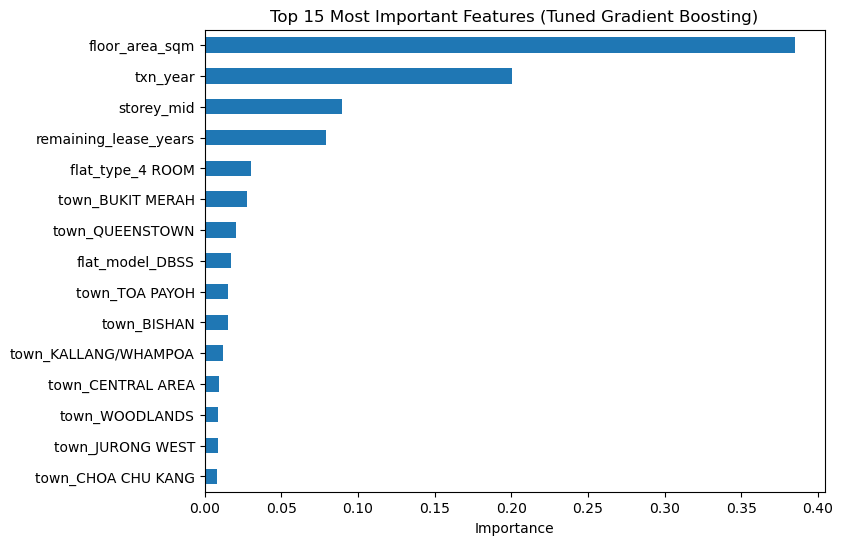

In [22]:
## Feature importance: which features the final model relies on most
importances = pd.Series(tuned_gbr.feature_importances_, index=X_train.columns)
importances.sort_values().tail(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Most Important Features (Tuned Gradient Boosting)')
plt.xlabel('Importance')
plt.show()
## interpretation:
# Floor area is by far the most important feature (about 39% of the model's decisions),
# followed by transaction year (~20%), storey (~9%) and remaining lease (~8%). The town
# and flat model columns each add a smaller amount on their own, but together they help
# the model price specific locations and premium models (BUKIT MERAH and DBSS flats stand
# out most). This matches what I saw in the EDA and confirms my engineered features
# (storey_mid, remaining_lease_years, txn_year) are genuinely useful.

In [23]:
## New data. One example flat, like a user would enter in the app
new_flat = pd.DataFrame([{
    'floor_area_sqm': 90,
    'remaining_lease_years': 70,
    'storey_mid': 11,
    'txn_year': 2026,
    'town': 'ANG MO KIO',
    'flat_type': '4 ROOM',
    'flat_model': 'Model A',
}])

## Preprocess it the same way as the training data. One hot encode, then line up the columns.
## reindex adds any missing dummy columns as 0, so the shape matches the training features.
new_flat_encoded = pd.get_dummies(new_flat)
new_flat_encoded = new_flat_encoded.reindex(columns=X_train.columns, fill_value=0)

## Predict the price for this flat
predicted_price = tuned_gbr.predict(new_flat_encoded)[0]
print(f"Predicted resale price: ${predicted_price:,.0f}")

## Sanity check. A bigger flat should cost more, so I changed only the floor area and predicted again.
print("\nSanity check (increase floor area, price should go up):")
for area in [60, 90, 120, 150]:
    check = new_flat.copy()
    check['floor_area_sqm'] = area
    check_encoded = pd.get_dummies(check).reindex(columns=X_train.columns, fill_value=0)
    print(f"  {area} sqm -> ${tuned_gbr.predict(check_encoded)[0]:,.0f}")
## interpretation:
# The model gave a sensible price for a normal flat, and moved the right way when I changed
# the inputs. Making the flat bigger steadily raised the predicted price. A model that
# predicted a lower price for a bigger flat would be broken and confuse buyers in the app.

Predicted resale price: $619,012

Sanity check (increase floor area, price should go up):
  60 sqm -> $458,002
  90 sqm -> $619,012
  120 sqm -> $754,823
  150 sqm -> $884,332


## Iterative model development

My final model was not built in one shot. I improved it step by step, and every step is shown above.

1. Started with a simple **Linear Regression** (MAE ~$52,900).
2. Trained three stronger models and compared them on the same test set. **Random Forest** was the most accurate (MAE ~$27,800), but its saved file was over 1 GB, far too big to deploy.
3. Chose **Gradient Boosting** instead, because it is tiny (a few MB) and deployable, then **tuned** it with RandomizedSearchCV. Tuning cut its error by about 40% (from ~$48,900 to ~$29,100), making it almost as accurate as Random Forest.

Scoring every version the same way on the same test set keeps the comparison fair. This is the iterative process. Start simple, try stronger models, then pick and tune the best one that also fits my real world constraint that it has to deploy.

## Further feature engineering / feature selection

The feature importance chart shows that a few features (floor area, transaction year, storey, remaining lease) do most of the work, while the many town and flat model columns each score low on their own.

Because each of those columns looks unimportant by itself, I considered dropping them (feature selection). Before deciding, I tested it by training the same tuned model on only the four strong numeric features and comparing it to the full model on the same test set.

In [24]:
# Feature selection test. Each town and flat model column has low importance on its own,
# so I checked whether dropping them helps. I compare my tuned model (all 55 features)
# against the same settings trained on only the four strong numeric features.
top_features = ['floor_area_sqm', 'remaining_lease_years', 'storey_mid', 'txn_year']

full_mae = mean_absolute_error(y_test, tuned_gbr.predict(X_test))
full_r2 = r2_score(y_test, tuned_gbr.predict(X_test))

reduced_gbr = GradientBoostingRegressor(**gbr_search.best_params_, random_state=2026)
reduced_gbr.fit(X_train[top_features], y_train)
reduced_mae = mean_absolute_error(y_test, reduced_gbr.predict(X_test[top_features]))
reduced_r2 = r2_score(y_test, reduced_gbr.predict(X_test[top_features]))

print("All 55 features (final model)")
print(f"  MAE = ${full_mae:,.0f}   R2 = {full_r2:.3f}")
print("Only 4 numeric features")
print(f"  MAE = ${reduced_mae:,.0f}   R2 = {reduced_r2:.3f}")
## interpretation:
# Dropping the town and flat model columns almost doubles the error, from ~$29,100 MAE up
# to ~$59,900, and R2 falls from 0.954 to 0.798. So even though each of those columns has
# low importance on its own, together they carry the location and flat model information
# that the EDA showed drives price. Keeping them clearly helps, so I did not drop any
# features and my final model uses all 55.

All 55 features (final model)
  MAE = $29,055   R2 = 0.954
Only 4 numeric features
  MAE = $59,876   R2 = 0.798


## Save the final model for deployment

I saved two things to files, the trained model and the exact list of feature columns (in order). The Streamlit app loads both to turn a user's inputs into a prediction. The model file is only a few MB, so it fits easily on GitHub (well under the 100 MB limit).

In [25]:
## Save the final model and the column list the app needs
joblib.dump(tuned_gbr, "hdb_price_model.pkl")             # the trained model (a few MB)
joblib.dump(list(X_train.columns), "model_columns.pkl")   # the 55 feature columns, in the right order

print("Saved: hdb_price_model.pkl and model_columns.pkl")

Saved: hdb_price_model.pkl and model_columns.pkl
